# Comparaison des 4 stratégies ALM

Ce notebook compare :
- **GBI**
- **TARGET_DATE**
- **FIXED_MIX**
- **FALEH**

Sur la même base de scénarios économiques (Monte Carlo), avec :
- KPI de performance/risque
- visualisations comparatives

In [11]:
import os, sys

project_root = os.path.abspath('.')
if not os.path.exists(os.path.join(project_root, 'config')):
    project_root = os.path.abspath('..')
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Répertoire de travail : {os.getcwd()}")

Répertoire de travail : c:\Users\maxhe\Desktop\HSBC-Retirement-ALM\ALM_modulaire


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from config import settings
from data import loader
from src import economics
from src.analytics import metrics, plotting
from src.economics.yield_curve import YieldCurveBuilder
from src.liabilities.goal_price_index import GoalPriceIndex
from src import strategies
from src.engine import run_simulation, run_simulation_gbi

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


In [13]:
# Paramètres d'exécution (ajuste si besoin)
USE_QUICK_MODE = True
NB_SIMS_QUICK = 2000
FALEH_STAGES_QUICK = 8

# Sauvegarde des paramètres initiaux
_original = {
    'NB_SIMULATIONS': settings.NB_SIMULATIONS,
    'FALEH_NB_TREE_STAGES': settings.FALEH_NB_TREE_STAGES
}

if USE_QUICK_MODE:
    settings.NB_SIMULATIONS = min(settings.NB_SIMULATIONS, NB_SIMS_QUICK)
    settings.FALEH_NB_TREE_STAGES = min(settings.FALEH_NB_TREE_STAGES, FALEH_STAGES_QUICK)

NB_SIMS = settings.NB_SIMULATIONS
NB_MOIS = settings.NB_PERIODES_TOTAL
DATES = pd.date_range(start=settings.DATE_DEBUT_T0, periods=NB_MOIS, freq='ME')

print(f"Mode rapide        : {USE_QUICK_MODE}")
print(f"Simulations        : {NB_SIMS}")
print(f"Stages FALEH       : {settings.FALEH_NB_TREE_STAGES}")
print(f"Horizon (mois)     : {NB_MOIS}")

Mode rapide        : True
Simulations        : 2000
Stages FALEH       : 8
Horizon (mois)     : 480


In [14]:
# 1) Paramètres marché + scénarios
mu_e, sigma_e, mu_b, sigma_b, corr_eb = loader.load_market_parameters()

r_eq, r_bd, idx_split = economics.generators.generer_rendements_avec_backtest(
    mu_e, sigma_e, mu_b, sigma_b, corr_eb, DATES, settings.DATE_PIVOT_BACKTEST, NB_SIMS
)

if getattr(settings, 'SIMULER_CRISE_MERTON', False):
    r_eq, r_bd = economics.shocks.ajouter_chocs_merton(
        r_eq, r_bd, settings.NB_PERIODES_TOTAL, NB_SIMS
    )

if getattr(settings, 'SIMULER_CRISE_LOCALISEE', False):
    date_crise_ts = pd.Timestamp(settings.DATE_CRISE)
    date_pivot_ts = pd.Timestamp(settings.DATE_PIVOT_BACKTEST)
    if date_crise_ts > date_pivot_ts:
        r_eq, r_bd = economics.shocks.injecter_crise_localisee(
            r_eq, r_bd, DATES, settings.DATE_CRISE, settings.PARAMS_CRISE_DETAIL
        )

print('Scénarios générés')
print(f'  - shape r_eq: {r_eq.shape}')
print(f'  - shape r_bd: {r_bd.shape}')
print(f'  - idx_split : {idx_split}')

Scénarios générés
  - shape r_eq: (480, 2000)
  - shape r_bd: (480, 2000)
  - idx_split : 284


In [15]:
# 2) Exécution des 4 stratégies
resultats = {}
contextes = {}

# --- GBI ---
yc = YieldCurveBuilder().load_from_csv(settings.CSV_YIELD_CURVE)
gpi = GoalPriceIndex(
    yield_curve=yc,
    retirement_date=settings.DATE_RETRAITE_GBI,
    dec_years=settings.DUREE_DECUMULATION_GBI
)

mat_cap_gbi, courbe_inv_gbi, hist_app_gbi, hist_dd_gbi, hist_sal_gbi, hist_alloc_gbi = run_simulation_gbi(
    gpi, r_eq, r_bd, DATES, idx_split
)
resultats['GBI'] = mat_cap_gbi
contextes['GBI'] = (courbe_inv_gbi, hist_app_gbi, hist_dd_gbi, hist_sal_gbi)

# --- TARGET_DATE ---
tdf = strategies.TargetDateStrategy()
mat_cap_tdf, courbe_inv_tdf, hist_app_tdf, hist_dd_tdf, hist_sal_tdf = run_simulation(
    tdf, r_eq, r_bd, DATES
)
resultats['TARGET_DATE'] = mat_cap_tdf
contextes['TARGET_DATE'] = (courbe_inv_tdf, hist_app_tdf, hist_dd_tdf, hist_sal_tdf)

# --- FIXED_MIX ---
fm = strategies.FixedMixStrategy()
mat_cap_fm, courbe_inv_fm, hist_app_fm, hist_dd_fm, hist_sal_fm = run_simulation(
    fm, r_eq, r_bd, DATES
)
resultats['FIXED_MIX'] = mat_cap_fm
contextes['FIXED_MIX'] = (courbe_inv_fm, hist_app_fm, hist_dd_fm, hist_sal_fm)

# --- FALEH ---
from src.strategies.faleh_strategy import FalehStrategy
faleh = FalehStrategy(mu_e, sigma_e, mu_b, sigma_b, corr_eb)
faleh.initialize_tree(DATES)
mat_cap_faleh, courbe_inv_faleh, hist_app_faleh, hist_dd_faleh, hist_sal_faleh = run_simulation(
    faleh, r_eq, r_bd, DATES
)
resultats['FALEH'] = mat_cap_faleh
contextes['FALEH'] = (courbe_inv_faleh, hist_app_faleh, hist_dd_faleh, hist_sal_faleh)

print('Simulations terminées :')
for nom, mat in resultats.items():
    print(f"  - {nom:<12} P50 final = {np.percentile(mat[-1,:], 50):,.0f} EUR")


 Construction de l'arbre de scénarios Faleh...
   • Profil : AGRESSIF
   • Gamma (aversion risque) : 1.50
   • Scénarios : 2000
   • Stages : 10
   • Scénarios générés en 7.79 secondes
   • Arbre construit en 15.53 secondes

STRUCTURE DE L'ARBRE DE SCÉNARIOS
Stage 0 (t=  0) :   1 nœuds | Prob totale: 1.000
Stage 1 (t= 53) :   3 nœuds | Prob totale: 1.000
              → 3 transitions depuis stage 0
Stage 2 (t=106) :   9 nœuds | Prob totale: 1.000
              → 9 transitions depuis stage 1
Stage 3 (t=159) :  27 nœuds | Prob totale: 1.000
              → 27 transitions depuis stage 2
Stage 4 (t=212) :  81 nœuds | Prob totale: 1.000
              → 81 transitions depuis stage 3
Stage 5 (t=266) : 227 nœuds | Prob totale: 1.000
              → 227 transitions depuis stage 4
Stage 6 (t=319) : 538 nœuds | Prob totale: 1.000
              → 538 transitions depuis stage 5
Stage 7 (t=372) : 1003 nœuds | Prob totale: 1.000
              → 1003 transitions depuis stage 6
Stage 8 (t=425) : 1524 

In [16]:
# 3) Tableau comparatif KPI
rows = []

for nom in ['GBI', 'TARGET_DATE', 'FIXED_MIX', 'FALEH']:
    mat_cap = resultats[nom]
    courbe_inv, hist_app, hist_dd, hist_sal = contextes[nom]

    cap_fin = mat_cap[-1, :]
    total_investi = courbe_inv[-1]
    idx_med = np.argsort(cap_fin)[len(cap_fin)//2]

    tri = metrics.calculer_tri_annualise(settings.CAPITAL_INITIAL, hist_app, cap_fin[idx_med])
    kpi = metrics.calcul_kpi_complets(cap_fin, total_investi, mat_cap)

    rows.append({
        'Stratégie': nom,
        'P5': np.percentile(cap_fin, 5),
        'P50': np.percentile(cap_fin, 50),
        'P95': np.percentile(cap_fin, 95),
        'TRI médian (%/an)': tri,
        'Shortfall (%)': kpi['shortfall_prob'] * 100,
        'VaR95 (P5)': kpi['var_95'],
        'Dispersion P95-P5': kpi['dispersion'],
        'Sortino': kpi['sortino'],
        'Max Underwater (ans)': kpi['max_underwater']
    })

df_kpi = pd.DataFrame(rows).set_index('Stratégie').sort_values('P50', ascending=False)
display(df_kpi.style.format({
    'P5': '{:,.0f}',
    'P50': '{:,.0f}',
    'P95': '{:,.0f}',
    'TRI médian (%/an)': '{:.2f}',
    'Shortfall (%)': '{:.2f}',
    'VaR95 (P5)': '{:,.0f}',
    'Dispersion P95-P5': '{:,.0f}',
    'Sortino': '{:.2f}',
    'Max Underwater (ans)': '{:.1f}'
}))

,P5,P50,P95,TRI médian (%/an),Shortfall (%),VaR95 (P5),Dispersion P95-P5,Sortino,Max Underwater (ans)
Stratégie,,,,,,,,,
FIXED_MIX,"375,225","876,207","2,105,867",5.05,2.15,"375,225","1,730,642",1.70,3.5
GBI,"406,503","859,738","1,970,292",4.97,1.00,"406,503","1,563,788",1.88,4.6
TARGET_DATE,"397,716","859,279","1,914,462",4.96,1.25,"397,716","1,516,746",1.71,4.2
FALEH,"449,390","737,360","1,224,591",4.28,0.20,"449,390","775,202",2.89,4.7


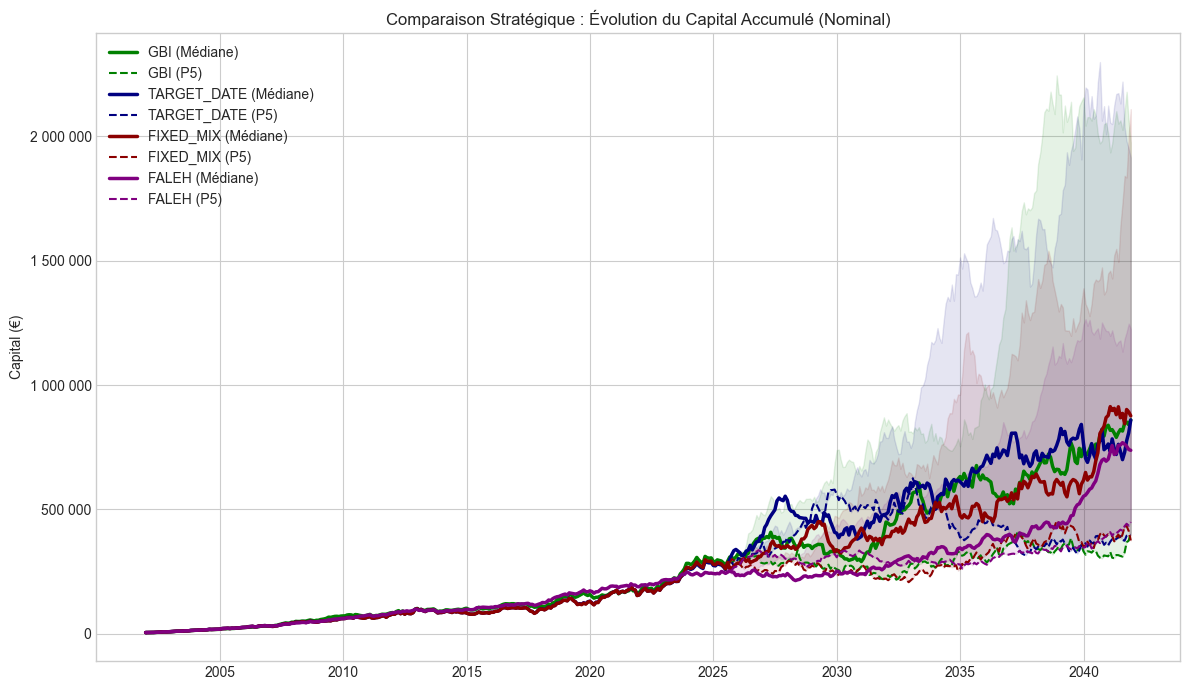

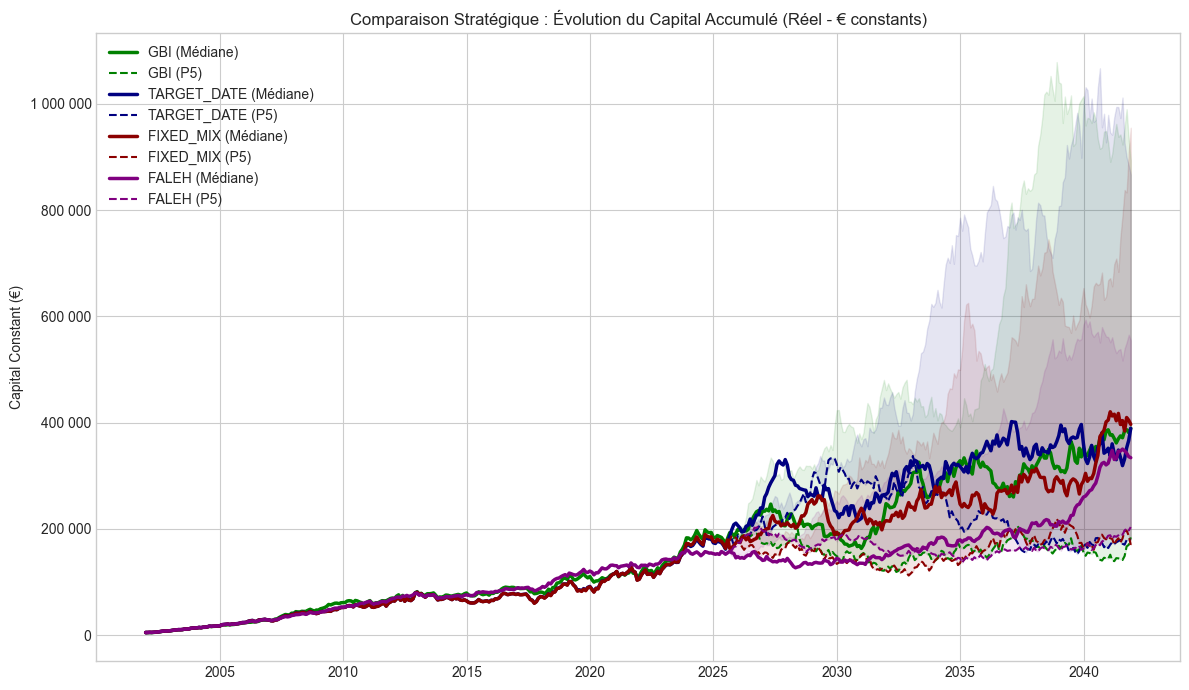

In [17]:
# 4) Graphique comparatif capital (nominal + réel)
plotting.plot_comparaison_capital(DATES, resultats, reel=False)
plotting.plot_comparaison_capital(DATES, resultats, reel=True)

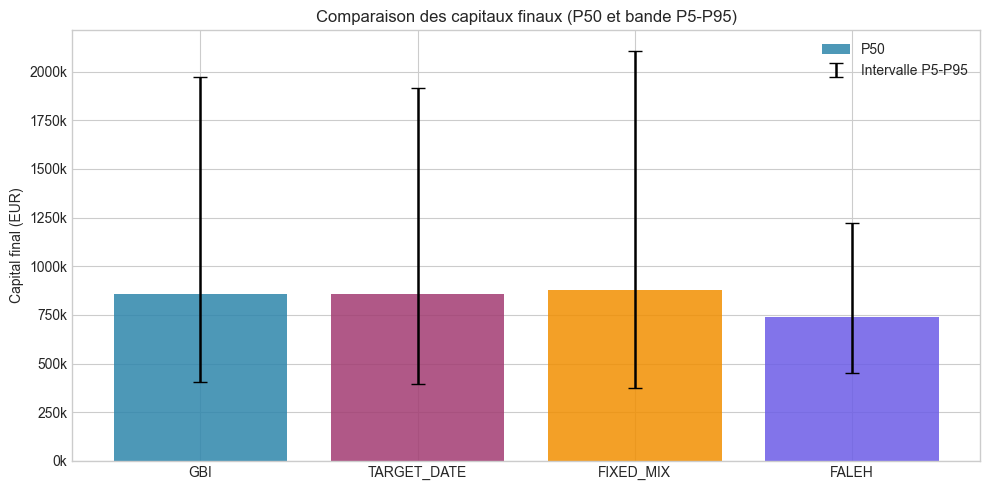

In [18]:
# 5) Visualisation synthétique des capitaux finaux
fig, ax = plt.subplots(figsize=(10, 5))
noms = ['GBI', 'TARGET_DATE', 'FIXED_MIX', 'FALEH']
p50_vals = [np.percentile(resultats[n][-1, :], 50) for n in noms]
p5_vals = [np.percentile(resultats[n][-1, :], 5) for n in noms]
p95_vals = [np.percentile(resultats[n][-1, :], 95) for n in noms]

x = np.arange(len(noms))
ax.bar(x, p50_vals, color=['#2E86AB','#A23B72','#F18F01','#6C5CE7'], alpha=0.85, label='P50')
ax.errorbar(x, p50_vals,
            yerr=[np.array(p50_vals) - np.array(p5_vals), np.array(p95_vals) - np.array(p50_vals)],
            fmt='none', ecolor='black', elinewidth=1.8, capsize=5, label='Intervalle P5-P95')

ax.set_xticks(x)
ax.set_xticklabels(noms)
ax.set_title('Comparaison des capitaux finaux (P50 et bande P5-P95)')
ax.set_ylabel('Capital final (EUR)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{int(v/1000)}k"))
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# 6) (Optionnel) Restaurer les settings initiaux
settings.NB_SIMULATIONS = _original['NB_SIMULATIONS']
settings.FALEH_NB_TREE_STAGES = _original['FALEH_NB_TREE_STAGES']
print('Settings restaurés.')

Settings restaurés.
